# LightCurve 表示機能開発

In [14]:
from astropy.table import Table
lc_tab=Table.read(f'data_LC/14d/4fgl_j0112.1+2245_lightcurve.fits')
lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd'])/2., name='t_mjd', index=0)


Text(0, 0.5, 'flux (cm$^{-2}$ s$^{-1}$)')

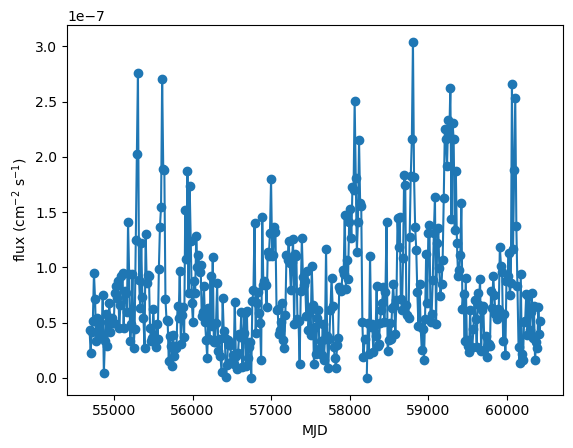

In [15]:
import matplotlib.pyplot as plt
# fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15,10))
lc_x=lc_tab['t_mjd']
lc_y=lc_tab['flux']
plt.plot(lc_x,lc_y ,marker='o')
# lightcurve,= plt.plot(lc_x[fermipresentbin],lc_y[fermipresentbin] ,marker='o',color='red')
# plt.set(xlim=[mjd_min, mjd_max], ylim=[0,0.3e-4])
plt.xlabel('MJD')
plt.ylabel('flux (cm$^{-2}$ s$^{-1}$)')

## GB6J


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['t_mjd', 'tmin', 'tmax', 'tmin_mjd', 'tmax_mjd', 'loglike_const', 'flux_const', 'fit_success', 'fit_success_fixed', 'fit_status', 'fit_quality', 'num_free_params', 'param_names', 'param_names_fixed', 'param_values', 'param_values_fixed', 'param_errors', 'param_errors_fixed', 'ts', 'ts_fixed', 'loglike', 'loglike_fixed', 'loglike_scan', 'loglike_scan_fixed', 'dloglike_scan', 'dloglike_scan_fixed', 'eflux_scan', 'eflux_scan_fixed', 'flux_scan', 'flux_scan_fixed', 'norm_scan', 'norm_scan_fixed', 'npred', 'npred_fixed', 'npred_wt', 'npred_wt_fixed', 'pivot_energy', 'pivot_energy_fixed', 'flux', 'flux_fixed', 'flux100', 'flux100_fixed', 'flux1000', 'flux1000_fixed', 'flux10000', 'flux10000_fixed', 'flux_err', 'flux_err_fixed', 'flux100_err', 'flux100_err_fixed', 'flux1000_err', 'flux1000_err_fixed', 'flux10000_err', 'flux10000_err_fixed', 'flux_ul95', 'flux_ul95_fixed', 'flux100_ul95', 'flux100_ul95_fixed', 'flux1000_ul95', 'flux1000_ul95_fixed', 'flux10000_ul95', 'flux10000_ul95_fixed', '

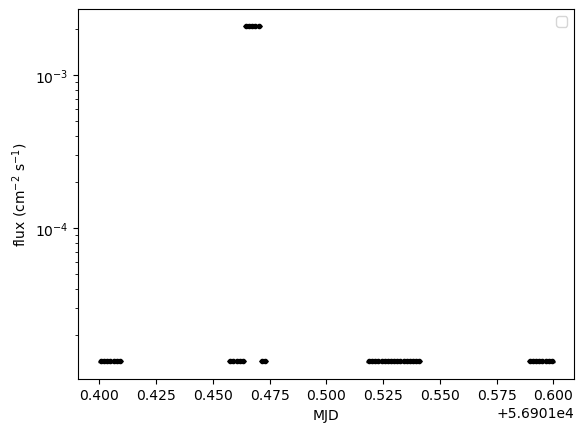

In [51]:
from astropy.table import Table
import numpy as np

# lc_tab=Table.read(f'data_LC/1d/4fgl_j1040.5+0617_lightcurve.fits')
# lc_tab=Table.read(f'data_LC/1d/4fgl_j1040.5+0617_lightcurve_1h.fits')
# lc_tab=Table.read(f'data_LC/1d/4fgl_j1040.5+0617_lightcurve_10min.fits')
lc_tab=Table.read(f'data_LC/1d/4fgl_j1040.5+0617_lightcurve_2min.fits')
lc_tab.add_column((lc_tab['tmax_mjd'] + lc_tab['tmin_mjd'])/2., name='t_mjd', index=0)
import matplotlib.pyplot as plt
# fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15,10))
lc_x=lc_tab['t_mjd']
lc_y=lc_tab['flux']
print(lc_tab.colnames)
# print(np.round(lc_tab['ts'].data,2))
# print(lc_tab['flux'].data)
# print(np.round(lc_tab['t_mjd'].data,3))
for i in range(40, 60):
    print(np.round(lc_tab['t_mjd'][i],3),' : ',
          np.round(lc_tab['ts'][i],2), ' : ',
          # lc_tab['flux1000'][i], ' : ',
          # lc_tab['flux1000_err'][i]
          lc_tab['flux'][i], ' : ',
          lc_tab['flux_err'][i], ' : '
          )
# print(np.round(lc_tab['t_mjd'][45],3),' : ',
#       np.round(lc_tab['ts'][45],2))


# plt.plot(lc_x,lc_y ,marker='o')
plt.errorbar(lc_x, lc_y, yerr=lc_tab['flux_err'], fmt='o', markersize=3, capsize=2, elinewidth=1, color='black')

# err=np.ones(len(sed_tab_nosignificant))*sed_tab_nosignificant['e2dnde_ul']*0.5
# axes[1].errorbar(sed_tab_nosignificant['e_ref'], sed_tab_nosignificant['e2dnde_ul'] ,
#                  yerr=err,
#                  uplims=True,
#                  linestyle='None',color='red',ecolor='red',capsize=3)

# plt.plot(lc_x,lc_tab['flux_ul95'] ,marker='o', label = 'UL')
# lightcurve,= plt.plot(lc_x[fermipresentbin],lc_y[fermipresentbin] ,marker='o',color='red')
# plt.xlim(56895, 56901)
plt.xlabel('MJD')
plt.ylabel('flux (cm$^{-2}$ s$^{-1}$)')
plt.yscale('log')
# plt.ylim(1e-6,1e-4)
# plt.xlim(56890, 56910)
# plt.ylim(1e-13,1e-4)
# plt.xlim(56900, 56903)
# plt.xlim(56901.3, 56901.7)
# plt.ylim(1e-13,1e-2)
# plt.xlim(56901.2, 56901.7)
# plt.ylim(1.2e-16,1.4e-2)
# plt.xlim(56901.45, 56901.5)
# plt.ylim(1.2e-4,1)
plt.legend()

# 天体名探索

In [16]:
from astropy.io import fits
import numpy as np

hdu=fits.open('/Users/kazuma/Workspace/Torun/Fermi/catalog/gll_psc_v35.fit')
significances = hdu[1].data['Signif_Avg']
sources = hdu[1].data['Source_Name']
sources1 = hdu[1].data['ASSOC1']
sources2 = hdu[1].data['ASSOC2']
sources_cls=hdu[1].data['CLASS1']
#Convert source classes to normal array without empty spaces
source_classes = np.array([entry.strip() for entry in hdu[1].data['CLASS1']])
#Filter by source class:
source_classes_selected = np.array(["bll","fsrq","BLL","FSRQ"],dtype='<U5') #see table 5 in https://arxiv.org/pdf/2201.11184
element_map = np.isin(source_classes, source_classes_selected)
significances_blazars= significances[element_map]
sources_blazars = sources[element_map]
sources_blazars1 = sources1[element_map]
sources_blazars2 = sources2[element_map]
sources_blazars_cls = source_classes[element_map]
#Get index of 20 brightes sources:
idx = (-significances_blazars).argsort()[:50]
#Get the same of the 20 most significant blazars:
# print(sources_blazars[idx])
from astropy.table import Table
t = Table([sources_blazars[idx],
       sources_blazars1[idx],
       sources_blazars_cls[idx]
       ],names=['4FGL name','assoc name','CLASS'])

d = dict(zip(t['4FGL name'],t['assoc name']))


## 文字列変換が必要
### クエリが動かない

In [17]:
mask=(t['4FGL name'] == '4FGL J0112.1+2245')
t[mask]
print(mask)
print(t[mask])
# t['4FGL name']

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False]
4FGL name assoc name CLASS
--------- ---------- -----


### -> 末尾余白は空白が付加されている

In [18]:
d['4FGL J2253.9+1609 ']

'3C 454.3                    '

### 空白削除: strip(), 空白置換: replace(), 大文字->小文字変換: lower()

In [19]:
print('3C 454.3                    '.strip(), end='*\n')
print(d['4FGL J2253.9+1609 '].strip(), end='*\n')
print(str(d['4FGL J2253.9+1609 ']).strip(), end='*\n')

print('3C 454.3                    '.strip().replace(' ','_'), end='*\n')
print('3C 454.3                    '.strip().replace(' ','_').lower(), end='*\n')


3C 454.3*
3C 454.3*
3C 454.3*
3C_454.3*
3c_454.3*


## Table作成
### 文字列変換はTable作成と同時にはできなさそう

In [20]:
ref_tab_ojb = Table([str(sources_blazars).strip().replace(' ','_').lower()[idx],
       str(sources_blazars1).strip().replace(' ','_').lower()[idx],
       sources_blazars_cls.strip()[idx]
       ],names=['4FGL name','assoc name','CLASS'])

TypeError: only integer scalar arrays can be converted to a scalar index

### 一段噛ませる

In [21]:
sources_blazars_converted  = sources_blazars.strip().replace(' ','_').lower()
sources_blazars1_converted = sources_blazars1.strip().replace(' ','_').lower()
sources_blazars_cls_converted = str(sources_blazars_cls).strip()


In [22]:
ref_tab_obj = Table([sources_blazars_converted[idx],
                    sources_blazars1_converted[idx],
                    sources_blazars_cls[idx]],
                    names=['4FGL name','assoc name','CLASS'])

In [23]:
ref_tab_obj[ref_tab_obj['4FGL name'] == '4fgl_j0112.1+2245']

4FGL name,assoc name,CLASS
str18,str28,str5
4fgl_j0112.1+2245,s2_0109+22,BLL
